# **Economics of Emissions** 
### Prediction Analysis of the Contribution of Emissions to the GDP of the states in the United States of America using a Cluster-Spatio-Temporal Approach

## - Data Preparation

### Merging Datasets

In [1]:
# Data Importation
import pandas as pd

# Path to your CSV file
file_path = ['Cleaned_Emissions_Yearly.csv', 'Cleaned_GDP_Yearly.csv', 'Clustered_emissions.csv']

# IMporting Data
df_full_emissions = pd.read_csv(file_path[0])
df_GDP = pd.read_csv(file_path[1])
df_Clustered_emissions = pd.read_csv(file_path[2])



In [2]:
# Data Overview
df_full_emissions.head()

,Country,State,Year,Emission
0,United States,Alabama,1990,42341.939842
1,United States,Alabama,1991,39217.818686
2,United States,Alabama,1992,36762.376140
3,United States,Alabama,1993,36945.520425
4,United States,Alabama,1994,37441.987568


In [3]:
# Data Overview
df_GDP.head()

,Year,State_Name,Manufacturing_GDP
0,2005,Alabama,124746.1
1,2005,Alaska,6973.7
2,2005,Arizona,73625.7
3,2005,Arkansas,77442.4
4,2005,California,846801.0


In [4]:
# Data Overview
df_Clustered_emissions.head()

,State,Combined_Emissions_Cluster,Fossil_CO2_Cluster,CH4_AR5_Cluster,N2O_AR5_Cluster,FGases_AR5_Cluster
0,Alabama,2,0,3,2,1
1,Alaska,2,1,0,0,1
2,Arizona,2,1,0,0,1
3,Arkansas,2,0,0,2,1
4,California,0,2,0,2,2


In [5]:
# Renaming State_name to State in GDP data
df_GDP = df_GDP.rename(columns={'State_Name': 'State'})

#Merging Full Emisions and GDP datasets
df_merged = pd.merge(
    df_full_emissions,
    df_GDP,
    on=['State', 'Year'],
    how='inner'  
)

# Data Overview
df_merged.head()

,Country,State,Year,Emission,Manufacturing_GDP
0,United States,Alabama,2005,38438.333574,124746.1
1,United States,Alabama,2006,37589.532157,129962.3
2,United States,Alabama,2007,37492.121948,127914.5
3,United States,Alabama,2008,36750.148784,127573.8
4,United States,Alabama,2009,32675.372179,108693.7


In [6]:
# Checking Data Information
print(df_merged.shape)
df_merged.info()

(969, 5)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 969 entries, 0 to 968
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            969 non-null    object 
 1   State              969 non-null    object 
 2   Year               969 non-null    int64  
 3   Emission           969 non-null    float64
 4   Manufacturing_GDP  969 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 45.4+ KB


In [7]:
# Mapping the clusters in clustered emissions to the respective states in the merged data. 
df_merged = pd.merge(
    df_merged,
    df_Clustered_emissions,
    on='State',
    how='left'  
)

# Data Overview
df_merged.head()

,Country,State,Year,Emission,Manufacturing_GDP,Combined_Emissions_Cluster,Fossil_CO2_Cluster,CH4_AR5_Cluster,N2O_AR5_Cluster,FGases_AR5_Cluster
0,United States,Alabama,2005,38438.333574,124746.1,2.0,0.0,3.0,2.0,1.0
1,United States,Alabama,2006,37589.532157,129962.3,2.0,0.0,3.0,2.0,1.0
2,United States,Alabama,2007,37492.121948,127914.5,2.0,0.0,3.0,2.0,1.0
3,United States,Alabama,2008,36750.148784,127573.8,2.0,0.0,3.0,2.0,1.0
4,United States,Alabama,2009,32675.372179,108693.7,2.0,0.0,3.0,2.0,1.0


In [90]:
# Saving Data
df_merged.to_csv("Final_Emissions_GDP.csv", index=False)

### Encoding the clusters

In [8]:
cluster_cols = [
    'Fossil_CO2_Cluster',
    'CH4_AR5_Cluster',
    'N2O_AR5_Cluster',
    'FGases_AR5_Cluster'
]

df_encoded = pd.get_dummies(df_merged, columns=cluster_cols, prefix=cluster_cols, drop_first=True)
print(df_encoded.head())

         Country    State  Year      Emission  Manufacturing_GDP  \
0  United States  Alabama  2005  38438.333574           124746.1   
1  United States  Alabama  2006  37589.532157           129962.3   
2  United States  Alabama  2007  37492.121948           127914.5   
3  United States  Alabama  2008  36750.148784           127573.8   
4  United States  Alabama  2009  32675.372179           108693.7   

   Combined_Emissions_Cluster  Fossil_CO2_Cluster_1.0  Fossil_CO2_Cluster_2.0  \
0                         2.0                       0                       0   
1                         2.0                       0                       0   
2                         2.0                       0                       0   
3                         2.0                       0                       0   
4                         2.0                       0                       0   

   CH4_AR5_Cluster_1.0  CH4_AR5_Cluster_2.0  CH4_AR5_Cluster_3.0  \
0                    0              

## Feature Engineering for Lagged Features

In [17]:
# Create lag features for emission and GDP
lag_features = ['Emission']
lagged_df = df_encoded.copy()

for feature in lag_features:
    lagged_df[f'{feature}_lag1'] = lagged_df.groupby('State')[feature].shift(1)

# Dropping missing rows from lag creation
lagged_df = lagged_df.dropna()
print(lagged_df.head())

         Country    State  Year      Emission  Manufacturing_GDP  \
1  United States  Alabama  2006  37589.532157           129962.3   
2  United States  Alabama  2007  37492.121948           127914.5   
3  United States  Alabama  2008  36750.148784           127573.8   
4  United States  Alabama  2009  32675.372179           108693.7   
5  United States  Alabama  2010  36401.119027           117264.4   

   Combined_Emissions_Cluster  Fossil_CO2_Cluster_1.0  Fossil_CO2_Cluster_2.0  \
1                         2.0                       0                       0   
2                         2.0                       0                       0   
3                         2.0                       0                       0   
4                         2.0                       0                       0   
5                         2.0                       0                       0   

   CH4_AR5_Cluster_1.0  CH4_AR5_Cluster_2.0  CH4_AR5_Cluster_3.0  \
1                    0              

### Defining Variables

In [18]:
# Target variable: Manufacturing GDP
y = lagged_df['Manufacturing_GDP']

# Dropping unused columns and target from predictors
X = lagged_df.drop(columns=['Country', 'State', 'Year', 'Manufacturing_GDP', 'Combined_Emissions_Cluster'])

In [19]:
# Checking Shapes of data
print(y.shape)
print(X.shape)

(900,)
(900, 11)


### Data Partitioning 

In [20]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Splitting into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

#Data Inspection
print(y_train.shape)
print(X_train.shape)

print(y_test.shape)
print(X_test.shape)

(675,)
(675, 11)
(225,)
(225, 11)


In [58]:
# Standardization of Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [59]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Model Perfromance Function
def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    metrics = {
        'Model': name,
        'R2_Train': r2_score(y_train, y_train_pred),
        'R2_Test': r2_score(y_test, y_test_pred),
        'RMSE_Test': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'MAE_Test': mean_absolute_error(y_test, y_test_pred),
        'MAPE_Test': np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100
    }
    return metrics


## Random Forest Model

In [60]:
from sklearn.ensemble import RandomForestRegressor

# Default Parameters Model
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled, y_train)

rf_train_pred = rf.predict(X_train_scaled)
rf_test_pred = rf.predict(X_test_scaled)

In [61]:
# Model Perfromance
evaluate_model(rf, X_train_scaled, X_test_scaled, y_train, y_test, "Random Forest(Default Parameters)")

{'Model': 'Random Forest(Default Parameters)',
 'R2_Train': 0.9765485146880366,
 'R2_Test': 0.9135493781633639,
 'RMSE_Test': 65829.11717111198,
 'MAE_Test': 37460.08201777777,
 'MAPE_Test': inf}

In [62]:
# Hyperparameters Tuning
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='r2', n_jobs=-1, verbose=1)
rf_grid.fit(X_train_scaled, y_train)
rf_best = rf_grid.best_estimator_

Fitting 3 folds for each of 24 candidates, totalling 72 fits


In [63]:
# Tuned Model Perfromance 
evaluate_model(rf_best, X_train_scaled, X_test_scaled, y_train, y_test, "Random Forest(Tuned)")

{'Model': 'Random Forest(Tuned)',
 'R2_Train': 0.9422946718587296,
 'R2_Test': 0.9130965576739518,
 'RMSE_Test': 66001.29546437945,
 'MAE_Test': 39628.90512959995,
 'MAPE_Test': inf}

## XGBoost Model

In [26]:
!pip install xgboost 

In [64]:
from xgboost import XGBRegressor

# Default Parameters Model
xgb = XGBRegressor(random_state=42, objective='reg:squarederror')
xgb.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [65]:
# Default Model Perfromance 
evaluate_model(xgb, X_train_scaled, X_test_scaled, y_train, y_test, "XGBoost (Default)")

{'Model': 'XGBoost (Default)',
 'R2_Train': 0.9647444636596769,
 'R2_Test': 0.893982638984565,
 'RMSE_Test': 72899.15006443024,
 'MAE_Test': 40130.06239171007,
 'MAPE_Test': inf}

In [66]:
# Hyperparameters Tuning
xgb_params = {
    'n_estimators': [200, 400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1]
}

xgb_grid = GridSearchCV(xgb, xgb_params, cv=3, scoring='r2', n_jobs=-1, verbose=1)
xgb_grid.fit(X_train_scaled, y_train)
xgb_best = xgb_grid.best_estimator_

Fitting 3 folds for each of 24 candidates, totalling 72 fits


In [67]:
# Tuned Model Perfromance 
evaluate_model(xgb_best, X_train_scaled, X_test_scaled, y_train, y_test, "XGBoost (Tuned)")

{'Model': 'XGBoost (Tuned)',
 'R2_Train': 0.9187403786318027,
 'R2_Test': 0.917787526457943,
 'RMSE_Test': 64195.24011853863,
 'MAE_Test': 41897.32200954861,
 'MAPE_Test': inf}

## Light GBM Model

In [33]:
!pip install lightgbm

In [68]:
from lightgbm import LGBMRegressor

# Default Parameters Model
lgb = LGBMRegressor(random_state=42)
lgb.fit(X_train_scaled, y_train)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000173 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 478
[LightGBM] [Info] Number of data points in the train set: 675, number of used features: 11
[LightGBM] [Info] Start training from score 155736.167234
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

LGBMRegressor(random_state=42)

In [69]:
# Default Model Perfromance 
evaluate_model(lgb, X_train_scaled, X_test_scaled, y_train, y_test, "LightGBM (Default)")

{'Model': 'LightGBM (Default)',
 'R2_Train': 0.921145316214241,
 'R2_Test': 0.9140667296879258,
 'RMSE_Test': 65631.84907487362,
 'MAE_Test': 40625.300665791794,
 'MAPE_Test': inf}

In [70]:
# Hyper Parameter Tuning
lgb_params = {
    'n_estimators': [200, 400],
    'max_depth': [5, 10, -1],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 50]
}

lgb_grid = GridSearchCV(lgb, lgb_params, cv=3, scoring='r2', n_jobs=-1, verbose=1)
lgb_grid.fit(X_train_scaled, y_train)
lgb_best = lgb_grid.best_estimator_

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000169 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 478
[LightGBM] [Info] Number of data points in the train set: 675, number of used features: 11
[LightGBM] [Info] Start training from score 155736.167234
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

In [71]:
# Tuned Model Perfromance 
evaluate_model(lgb_best, X_train_scaled, X_test_scaled, y_train, y_test, "LightGBM (Tuned)")

{'Model': 'LightGBM (Tuned)',
 'R2_Train': 0.9210910412314626,
 'R2_Test': 0.9141827429238321,
 'RMSE_Test': 65587.53134582742,
 'MAE_Test': 40565.20947094809,
 'MAPE_Test': inf}

## Model Performance Comparisons

In [72]:
# Creating Performance Results Table
results = []
results.append(evaluate_model(rf, X_train_scaled, X_test_scaled, y_train, y_test, "Random Forest(Default)"))
results.append(evaluate_model(rf_best, X_train_scaled, X_test_scaled, y_train, y_test, "Random Forest(Tuned)"))
results.append(evaluate_model(xgb, X_train_scaled, X_test_scaled, y_train, y_test, "XGBoost (Default)"))
results.append(evaluate_model(xgb_best, X_train_scaled, X_test_scaled, y_train, y_test, "XGBoost (Tuned)"))
results.append(evaluate_model(lgb, X_train_scaled, X_test_scaled, y_train, y_test, "LightGBM (Default)"))
results.append(evaluate_model(lgb_best, X_train_scaled, X_test_scaled, y_train, y_test, "LightGBM (Tuned)"))

performance_df = pd.DataFrame(results)
performance_df.sort_values(by='R2_Test', ascending=False)




,Model,R2_Train,R2_Test,RMSE_Test,MAE_Test,MAPE_Test
3,XGBoost (Tuned),0.918740,0.917788,64195.240119,41897.322010,inf
5,LightGBM (Tuned),0.921091,0.914183,65587.531346,40565.209471,inf
4,LightGBM (Default),0.921145,0.914067,65631.849075,40625.300666,inf
0,Random Forest(Default),0.976549,0.913549,65829.117171,37460.082018,inf
1,Random Forest(Tuned),0.942295,0.913097,66001.295464,39628.905130,inf
2,XGBoost (Default),0.964744,0.893983,72899.150064,40130.062392,inf


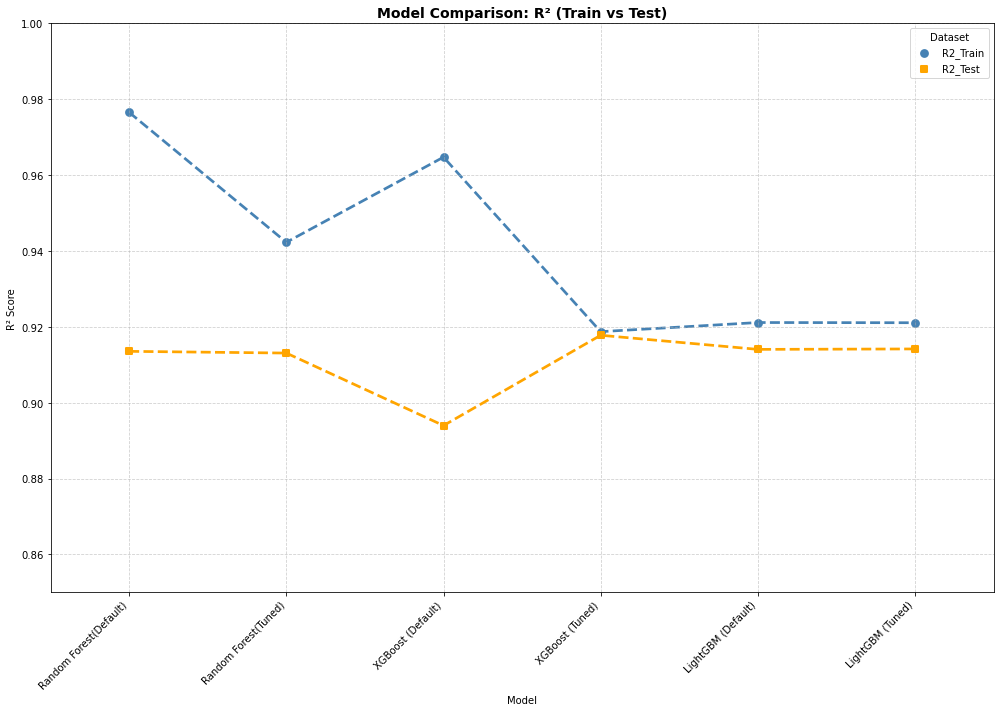

In [86]:
# Plots

#Reorganizing Data
df_r2 = performance_df.melt(
    id_vars='Model',
    value_vars=['R2_Train', 'R2_Test'],
    var_name='Dataset',
    value_name='R2_Score'
)

# Plot
plt.figure(figsize=(14, 10))
sns.pointplot(
    data=df_r2,
    x='Model', y='R2_Score', hue='Dataset',
    palette=['steelblue', 'orange'],
    markers=['o', 's'],
    linestyles='--'
)

plt.title('Model Comparison: R² (Train vs Test)', fontsize=14, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.85, 1.0)
plt.legend(title='Dataset')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

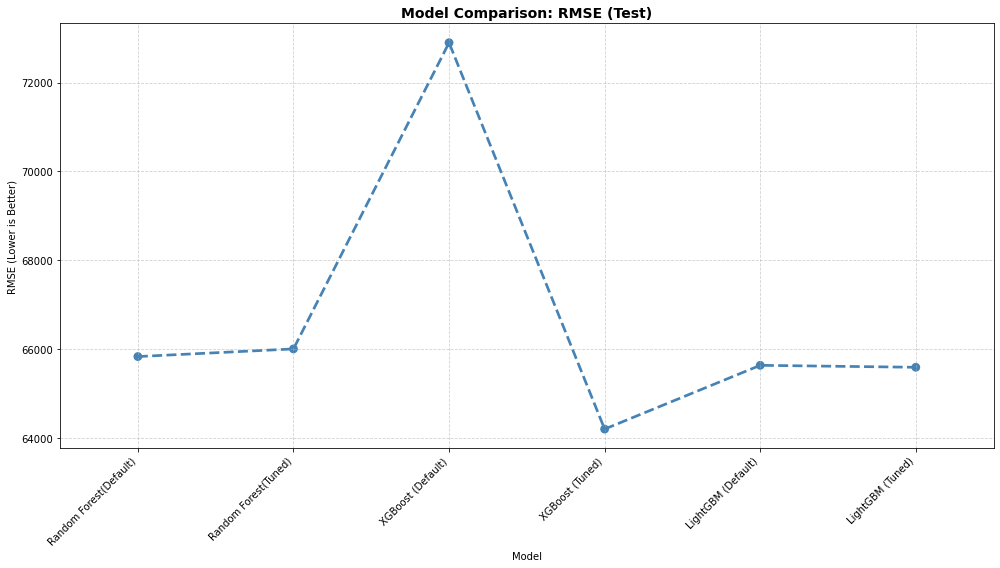

In [88]:
# RMSE Plot
plt.figure(figsize=(14, 8))
sns.pointplot(
    data=performance_df,
    x='Model', y='RMSE_Test',
    color='steelblue', markers='o', linestyles='--'
)

plt.title('Model Comparison: RMSE (Test)', fontsize=14, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('RMSE (Lower is Better)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

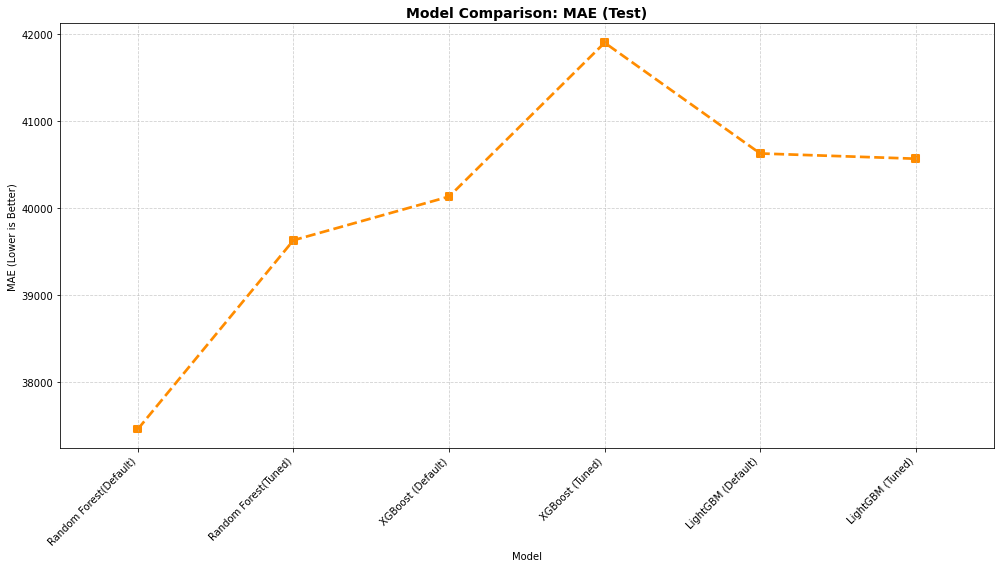

In [89]:
# MAE Plot
plt.figure(figsize=(14, 8))
sns.pointplot(
    data=performance_df,
    x='Model', y='MAE_Test',
    color='darkorange', markers='s', linestyles='--'
)

plt.title('Model Comparison: MAE (Test)', fontsize=14, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('MAE (Lower is Better)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Feature Importance

In [73]:
# Getting Importance Table
# Reaining feature names
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

# Get feature importance data
importance_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': xgb_best.feature_importances_
}).sort_values(by='Importance', ascending=False)
importance_df

,Feature,Importance
9,FGases_AR5_Cluster_2.0,0.612215
8,FGases_AR5_Cluster_1.0,0.276987
2,Fossil_CO2_Cluster_2.0,0.018060
7,N2O_AR5_Cluster_2.0,0.016466
0,Emission,0.014656
10,Emission_lag1,0.012363
5,CH4_AR5_Cluster_3.0,0.012127
4,CH4_AR5_Cluster_2.0,0.010954
3,CH4_AR5_Cluster_1.0,0.010665
6,N2O_AR5_Cluster_1.0,0.008174


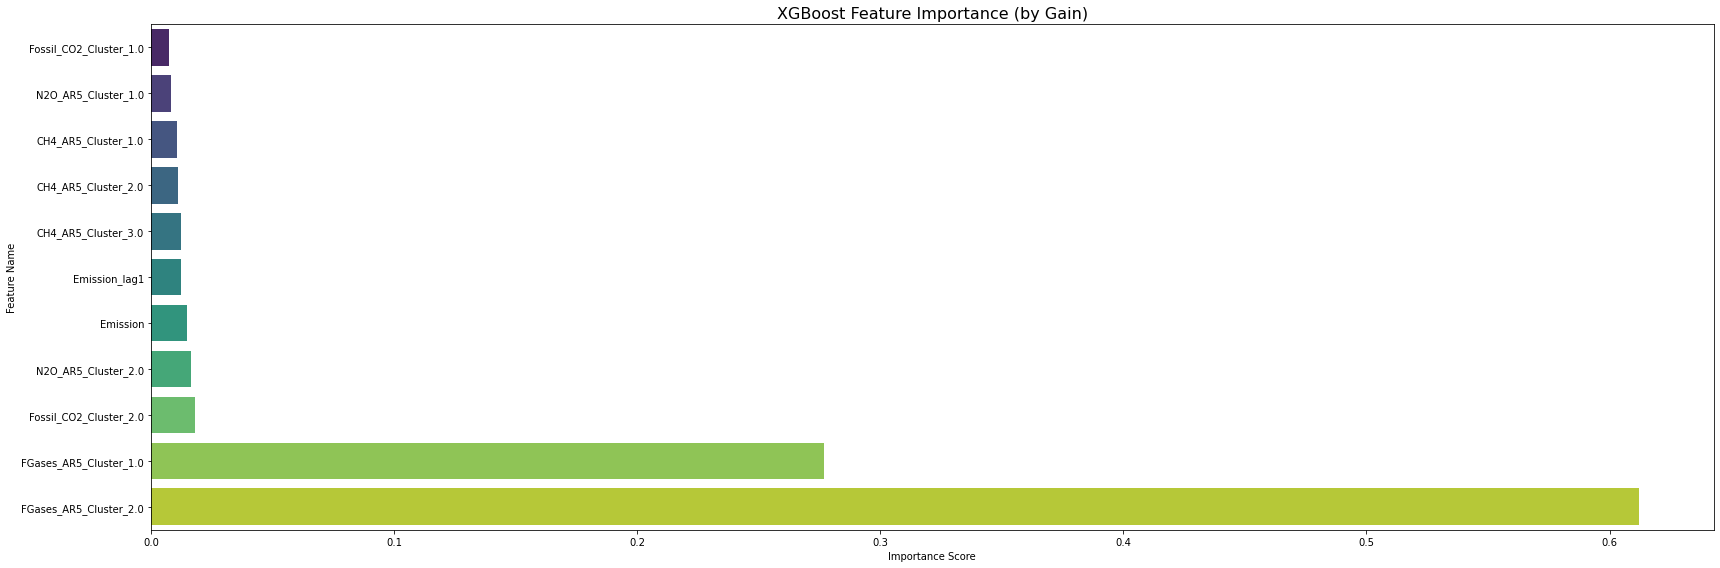

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by importance
importance_df_sorted = importance_df.sort_values(by='Importance', ascending=True)

# Plot feature importance
plt.figure(figsize=(24, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df_sorted,
    palette='viridis'
)
plt.title("XGBoost Feature Importance (by Gain)", fontsize=16)
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()